In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df = pd.read_csv('/home/parrot/Documents/machine_learning/datasets/Country-data.csv')  
print(df.head())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [9]:
df.shape

(167, 10)

In [10]:
df.describe

<bound method NDFrame.describe of                  country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2    

In [7]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


In [11]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
X = df.select_dtypes(include=[np.number])


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features ready for clustering:", X_scaled.shape)

Features ready for clustering: (167, 9)


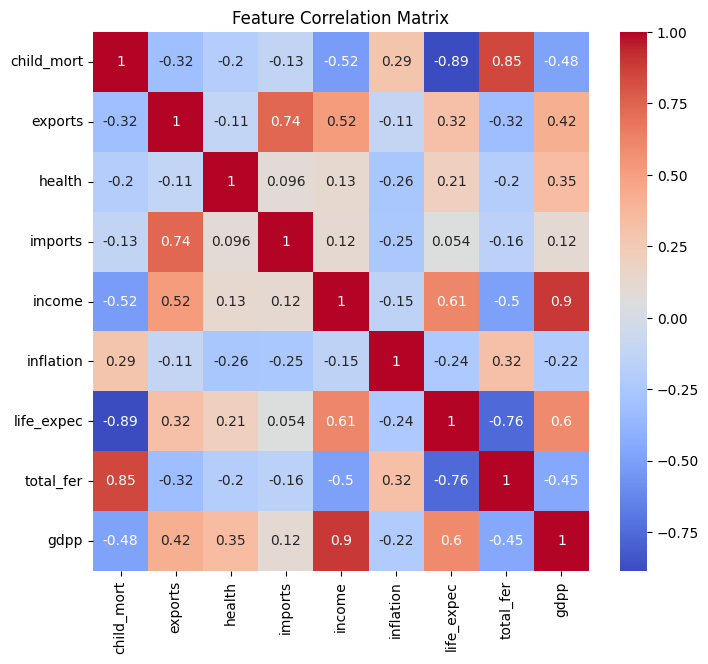

In [18]:
plt.figure(figsize=(8, 7))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


In [19]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [20]:
algorithms = {
    "KMeans": KMeans(n_clusters=4, random_state=42),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=3),  # tune based on data
    "AgglomerativeClustering": AgglomerativeClustering(n_clusters=4),
    "GaussianMixture": GaussianMixture(n_components=4, random_state=42)
}


In [21]:
for name, model in algorithms.items():
    print(f"\nRunning {name}...")
    
    if name == "GaussianMixture":
        labels = model.fit(X_scaled).predict(X_scaled)
    else:
        labels = model.fit_predict(X_scaled)
    
    # Silhouette score for evaluation
    try:
        score = silhouette_score(X_scaled, labels)
        print(f"Silhouette Score: {score:.2f}")
    except:
        print("Silhouette score cannot be calculated (single cluster)")
    
    print(f"Cluster assignment for first 10 countries: {labels[:10]}")
    
    # Add cluster labels to original dataframe for reference
    df[f'{name}_Cluster'] = labels



Running KMeans...
Silhouette Score: 0.29
Cluster assignment for first 10 countries: [2 0 0 2 0 0 0 1 1 0]

Running DBSCAN...
Silhouette Score: 0.15
Cluster assignment for first 10 countries: [ 0  0  0 -1  0  0  0  0  0  0]

Running AgglomerativeClustering...
Silhouette Score: 0.25
Cluster assignment for first 10 countries: [2 0 0 0 0 0 0 1 1 0]

Running GaussianMixture...
Silhouette Score: 0.20
Cluster assignment for first 10 countries: [2 0 0 2 0 0 0 1 1 2]
